# Exercise E3

This notebook produces the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [2]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

## Exercise 1: South Pole

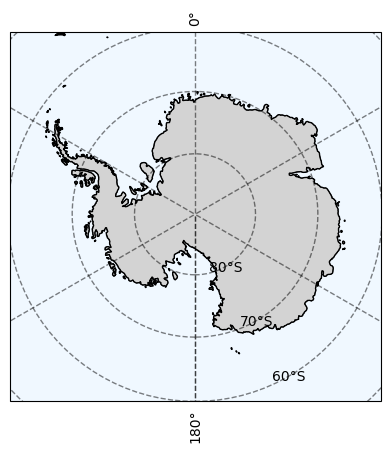

In [3]:
# Plotting map of Antarctica
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.coastlines()

# Setting extent: [Long min, Long max, Lat min, Lat max]
# Since it's a circular polar plot, we define the latitude limit (60S)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Adding features
ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Adding Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

## Exercise 2

[Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


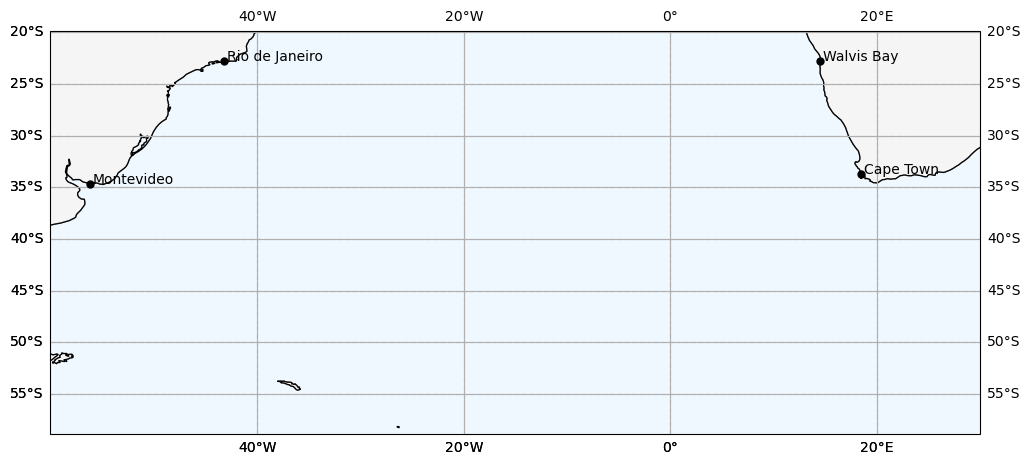

In [4]:
geolocator = Nominatim(user_agent='educational')
# a map of the Mediterranean, with a few places
extent = [-60, 30, -50, -20]
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])

place = ['Walvis Bay','Cape Town','Rio de Janeiro','Montevideo']
address = []
for p in place:
    loc = geolocator.geocode(p,language="en")
    address.append(loc)
print(address)

plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.set_extent(extent)

# Adding Features
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', edgecolor='dimgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Adding Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False
ax.gridlines(draw_labels=True)
for p in range(len(place)):
    ax.plot(address[p].longitude,address[p].latitude,'ko',markersize=5,transform=ccrs.Geodetic())
    ax.text(address[p].longitude+0.3,address[p].latitude,place[p],transform=ccrs.Geodetic()) 